In [2]:
import pyslammer as slam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import FancyArrowPatch
import itertools
from dataclasses import dataclass
%matplotlib widget

plt.style.use(slam.psfigstyle)

In [20]:
# Parameters
record_names = [
    # "Morgan_Hill_1984_CYC-285",
    "Nisqually_2001_UNR-058",
    "Imperial_Valley_1979_BCR-230",
    "Northridge_1994_PAC-175",
    # "Chi-Chi_1999_TCU068-090",
    "Cape_Mendocino_1992_PET-090",
    "Coalinga_1983_PVB-045",
    # "Mammoth_Lakes-2_1980_CVK-090",
    # "Kocaeli_1999_ATS-090",
    # "Nahanni_1985_NS1-280",
    "Mammoth_Lakes-1_1980_CVK-090",
    # "Duzce_1999_375-090",
    "Loma_Prieta_1989_HSP-000",
    # "Landers_1992_LCN-345",
    # "N_Palm_Springs_1986_WWT-180",
    # "Kobe_1995_TAK-090",
    "Coyote_Lake_1979_G02-050",
    "Northridge_1994_VSP-360",
]

histories = {k: v for k, v in slam.sample_ground_motions().items() if k in record_names}



In [21]:
for key, value in histories.items():
    print(value.mean_period)

0.6890810509341425
0.4709157570560458
0.4671016653371186
0.694972139471217
0.605886909343342
0.32047843807636567
1.026370957901247
0.3673243242373806
0.45746628528114175


In [22]:
def run_analysis(ky, vs_slope, motion_name, gm, method):
    """Run a single analysis for given parameters."""
    rigid_inputs = {
        "ky": ky,
        "ground_motion": gm,
        "target_pga": 0.44,
    }
    flex_inputs = {
        "height": 25.0,
        "vs_slope": vs_slope, #150.0,
        "vs_base": 1500.0,
        "damp_ratio": 0.05,
        "ref_strain": 0.0005,
        "soil_model": "equivalent_linear",
    }

    if method == "rigid":
        result = slam.RigidAnalysis(**rigid_inputs)
    elif method == "coupled":
        result = slam.Coupled(**rigid_inputs, **flex_inputs)
    else:
        raise ValueError("Not a valid method")

    return {
        "motion": motion_name,
        "method": method,
        "k_max": np.max(result.a_in),
        "ky": ky,
        "vs_slope":vs_slope,
        "d_max": result.max_sliding_disp,
    }


In [23]:
# Create two Segments, representing roadway alignments next to different slopes.
@dataclass
class Segment:
    name: str
    height: float
    ky_mean: float
    ky_cv: float
    vs_mean: float
    vs_cv: float
    vs_base: float

ky_cv = 0.2
vs_cv = 0.15
# Segment A
A = Segment("A", 25, 0.13,ky_cv, 250, vs_cv, 1500)
B = Segment("B", 25, 0.15, ky_cv, 400, vs_cv, 1500)
methods = ["rigid", "coupled"]

In [24]:
def sigma_ln(cv):
    return np.sqrt(np.log(cv**2 + 1))

In [25]:
sigma_ln(vs_cv)

np.float64(0.14916638004195087)

In [26]:
# Create numpy random generator
rng = np.random.default_rng(seed=42)  # Use seed for reproducibility

runs = 700
interval = 5

target_rmse = 0.05

In [27]:
all_results = []

for segment, method in list(
    itertools.product([A, B], ["coupled"])
): 
    results = []
    ky_std = segment.ky_mean * segment.ky_cv
    vs_std = segment.vs_cv * segment.vs_mean
    ky_mean_ln = np.log(segment.ky_mean**2 / np.sqrt(ky_std**2 + segment.ky_mean**2))
    ky_sigma_ln = np.sqrt(np.log(1 + (ky_std / segment.ky_mean) ** 2))
    vs_mean_ln = np.log(segment.vs_mean**2 / np.sqrt(vs_std**2 + segment.vs_mean**2))
    vs_sigma_ln = np.sqrt(np.log(1 + (vs_std / segment.vs_mean) ** 2))

    for run in range(runs):
        # Generate random ky value
        # ky = max(0.01, rng.lognormal(mu_ln, sigma_ln))
        # vs_slope = max(0, rng.normal(segment.vs_mean, segment.vs_cv * segment.vs_mean))
        for motion_name, gm in histories.items():
            ky = max(0.01, rng.lognormal(ky_mean_ln, ky_sigma_ln))
            vs_slope = max(0.01, rng.lognormal(vs_mean_ln, vs_sigma_ln))
            # vs_slope = max(0, rng.normal(segment.vs_mean, segment.vs_cv * segment.vs_mean))
            

            result = run_analysis(ky, vs_slope, motion_name, gm,method)
            result["segment"] = segment.name
            results.append(result)
        
        # Check convergence at intervals
        if (run + 1) % interval == 0:
            df_temp = pd.DataFrame(results)
            current_mean = df_temp["d_max"].mean()
            current_std = df_temp["d_max"].std()
            st_error = current_std / np.sqrt(len(results))
            
            print(
                f"Segment {segment.name} {results[-1]["method"]}, n = {len(results)}: Mean = {current_mean:.4f}, Std = {current_std:.4f}, % Rel. Std. Error = {100 * st_error / current_mean:.4f}"
            )

            if st_error / current_mean < target_rmse:
                break
    
    all_results.extend(results)

df = pd.DataFrame(all_results)


Segment A coupled, n = 45: Mean = 0.0439, Std = 0.0844, % Rel. Std. Error = 28.6144
Segment A coupled, n = 90: Mean = 0.0486, Std = 0.0878, % Rel. Std. Error = 19.0305
Segment A coupled, n = 135: Mean = 0.0534, Std = 0.0986, % Rel. Std. Error = 15.8962
Segment A coupled, n = 180: Mean = 0.0528, Std = 0.0942, % Rel. Std. Error = 13.2949
Segment A coupled, n = 225: Mean = 0.0514, Std = 0.0899, % Rel. Std. Error = 11.6670
Segment A coupled, n = 270: Mean = 0.0521, Std = 0.0923, % Rel. Std. Error = 10.7774
Segment A coupled, n = 315: Mean = 0.0533, Std = 0.0921, % Rel. Std. Error = 9.7322
Segment A coupled, n = 360: Mean = 0.0516, Std = 0.0894, % Rel. Std. Error = 9.1389
Segment A coupled, n = 405: Mean = 0.0519, Std = 0.0915, % Rel. Std. Error = 8.7662
Segment A coupled, n = 450: Mean = 0.0520, Std = 0.0935, % Rel. Std. Error = 8.4708
Segment A coupled, n = 495: Mean = 0.0520, Std = 0.0929, % Rel. Std. Error = 8.0349
Segment A coupled, n = 540: Mean = 0.0541, Std = 0.0938, % Rel. Std. Err

In [28]:
def find_crossing_point(x_data, y_data, x_threshold):
    """
    Find the coordinates where a curve crosses a given x-value threshold.
    
    Parameters:
    -----------
    x_data : array-like
        X coordinates of the curve
    y_data : array-like  
        Y coordinates of the curve
    x_threshold : float
        The x-value threshold to find the crossing point for
        
    Returns:
    --------
    tuple or None
        (x_threshold, y_interpolated) if crossing found, None otherwise
    """
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    # Check if threshold is within data range
    if x_threshold < x_data.min() or x_threshold > x_data.max():
        return None
    
    # Sort data by x values in case it's not sorted
    sort_idx = np.argsort(x_data)
    x_sorted = x_data[sort_idx]
    y_sorted = y_data[sort_idx]
    
    # Interpolate to find y value at x_threshold
    y_interp = np.interp(x_threshold, x_sorted, y_sorted)
    
    return (x_threshold, y_interp)

def prob_label(ax, x_rel, y_rel, segment, threshold, prob):
    ax.text(
        x_rel,
        y_rel,
        f"$P(D_{segment}>$ {100*threshold:.0f} cm$)$\n = {100 * prob:.0f} %",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=1),
        zorder=10,
    )



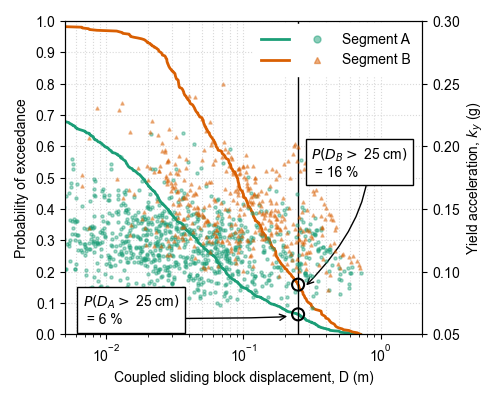

In [29]:
plt.close("all")
dm = 0.25
limits = [0.1]
label_location = {
    "A": (0.05, 0.13),
    "B": (0.69, 0.6)
}

fig, ax = plt.subplots(figsize=(5, 4))

# Create second y-axis for return period
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())


linestyles = {"rigid": "--", "coupled": "-"}
linews = {"rigid": 0.01, "coupled": 2}
colors = {"A": "#1b9e77", "B": "#d95f02"}
markers = {"A": "o", "B": "^"}

for segment in df["segment"].unique():
    df_seg = df[df["segment"] == segment]

for segment, method in list(
    itertools.product([A, B], ["coupled"])
):  # segment in df["segment"].unique():
    df_seg = df[df["segment"] == segment.name]
    df_seg = df_seg[df_seg["method"] == method]

    sorted_data = np.sort(df_seg["d_max"])
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(
        sorted_data,
        1 - cumulative,
        color=colors[segment.name],
        linewidth=linews[method],
        linestyle=linestyles[method],
        label=f"Segment {segment.name}",
    )
    edpx, edpy = find_crossing_point(sorted_data, 1-cumulative, dm)
    ax.scatter(edpx, edpy, marker="o", s=75, facecolors='none', edgecolors='black', linewidths=1.5, zorder=5)
    labelx = label_location[segment.name][0]
    labely = label_location[segment.name][1]
    asdf = prob_label(ax2, labelx, labely, segment.name, edpx, edpy)
    scatter = ax2.scatter(
        df_seg["d_max"],
        df_seg["ky"],
        c=colors[segment.name],  # grp["vs_slope"],
        marker=markers[segment.name],
        label=f"Segment {segment.name}",
        alpha=0.4,
        # cmap="viridis",
        # vmin=vmin,
        # vmax=vmax,
        s=5,
        zorder=2,
    )
    
ax.set_xlabel("Coupled sliding block displacement, D (m)")
ax.set_ylabel("Probability of exceedance")
ax.set_yticks(np.linspace(0,1,11))

# Damage levels and limits
# ax.scatter(dms, limits, marker="x", color="tab:red", s=25, zorder=5)
# for dm in dms:
ax.axvline(dm, color="k", linewidth=1)

# for limit in limits:
#     ax.axhline(limit, color="k", linewidth=0.5)

ax.set_ylim(0, 1)
ax2.set_ylim(0.05, 0.3)
ax2.set_ylabel("Yield acceleration, $k_y$ (g)")

# Create custom legend handles combining line and marker


legend_elements = []
for segment in [A, B]:
    # Create separate line and marker elements
    line_element = Line2D([0], [0], 
                         color=colors[segment.name], 
                         linestyle=linestyles["coupled"], 
                         linewidth=linews["coupled"])
    
    marker_element = Line2D([0], [0], 
                           marker=markers[segment.name], 
                           markersize=5,
                           markerfacecolor=colors[segment.name],
                           markeredgecolor=colors[segment.name],
                           alpha=0.5,
                           linestyle='None')
    
    # Combine them as a tuple for the legend
    legend_elements.append((line_element, marker_element))

# Create labels
labels = [f"Segment {segment.name}" for segment in [A, B]]

ax.legend(
    legend_elements,
    labels,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=1)},
    handlelength=5,
    loc="upper right",
    bbox_to_anchor=(1.01, 1.012),
    borderpad=0.6
    # bbox_to_anchor=(0.52, 0.98),
    # bbox_transform=fig.transFigure,
)#,
        #  loc="upper right")
ax.set_xlim(0.005,2)
ax.set_xscale("log")
ax.grid(which="both",linestyle=":", color="#d9d9d9")


# Linear regression

ax.plot([1e-3, 1e3], [1e-3, 1e3], color="black", linestyle="--", linewidth=1)


arrow = FancyArrowPatch(
    (0.85, 0.55),  # Start point (near text box)
    (0.67, 0.15),  # End point (middle of plot, on dashed line)
    connectionstyle="angle3,angleA=90,angleB=45",  # Angle connection style
    transform=ax.transAxes,
    arrowstyle="->",
    mutation_scale=11,
    color="black",
    alpha=1,
    zorder=4,
)

ax.add_patch(arrow)

arrow = FancyArrowPatch(
    (0.1, 0.05),  # Start point (near text box)
    (0.63, 0.06),  # End point (middle of plot, on dashed line)
    connectionstyle="angle3,angleA=180,angleB=-45",  # Angle connection style
    transform=ax.transAxes,
    arrowstyle="->",
    mutation_scale=11,
    color="black",
    alpha=1,
    zorder=4,
)

ax.add_patch(arrow)


plt.tight_layout()
fig.savefig("pbsd_example.pdf")
